# Baseline Models

This notebook trains the first baseline credit-risk models after split strategy and preprocessing.

The goal is to establish a simple, honest benchmark before moving to more advanced models such as Random Forest, XGBoost, or LightGBM.

## 1. Environment Setup

Load the required libraries, connect to the project source code, and set the random seed.

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from credit_risk_platform.data.german_credit import interim_german_credit_dir
from credit_risk_platform.utils.io import load_csv

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")

print("project_root:", project_root)
print("src_dir exists:", src_dir.exists())

project_root: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform
src_dir exists: True


## 2. Load the Standardized Dataset

Load the same standardized dataset used in earlier notebooks.

In [3]:
interim_dir = interim_german_credit_dir(project_root)
df = load_csv(interim_dir / "german_credit_standardized.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 24)


,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate_pct_income,personal_status_sex,...,other_installment_plans,housing,existing_credits_count,job_type,liable_people_count,telephone,foreign_worker,risk_class,risk_label,TARGET
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


## 3. Define Features and Target

Exclude identifiers and target-derived labels from model features.

In [4]:
target_col = "TARGET"
identifier_cols = ["applicant_id"]
target_label_cols = ["risk_class", "risk_label"]
exclude_from_features = identifier_cols + target_label_cols + [target_col]

feature_cols = [col for col in df.columns if col not in exclude_from_features]
X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature count:", len(feature_cols))
display(pd.DataFrame({"feature_cols": pd.Series(feature_cols)}))

Feature count: 20


,feature_cols
0,checking_account_status
1,duration_months
2,credit_history
3,purpose
4,credit_amount
5,savings_account
6,employment_duration
7,installment_rate_pct_income
8,personal_status_sex
9,other_debtors_guarantors


## 4. Recreate Train, Validation, and Test Splits

I used the same stratified split from Notebook 05 and Notebook 06.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Train:", X_train.shape)
print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Train: (700, 20)
Validation: (150, 20)
Test: (150, 20)


## 5. Build the Preprocessing Pipeline

I used the same baseline preprocessing logic from Notebook 06.

In [6]:
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()

try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 7
Categorical features: 13


## 6. Baseline Models

I start with simple models that are easy to explain and useful as benchmarks.

In [7]:
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "decision_tree_depth_4": DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE),
}

models

{'dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
 'logistic_regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'decision_tree_depth_4': DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=42)}

## 7. Train and Evaluate Baselines

Evaluate on the validation set first. Keep the test set untouched for final model comparison later.

In [8]:
def evaluate_classifier(model_name, fitted_pipeline, X_eval, y_eval):
    y_pred = fitted_pipeline.predict(X_eval)

    if hasattr(fitted_pipeline, "predict_proba"):
        y_score = fitted_pipeline.predict_proba(X_eval)[:, 1]
    else:
        y_score = y_pred

    return {
        "model": model_name,
        "accuracy": round(accuracy_score(y_eval, y_pred), 4),
        "balanced_accuracy": round(balanced_accuracy_score(y_eval, y_pred), 4),
        "precision_bad_risk": round(precision_score(y_eval, y_pred, zero_division=0), 4),
        "recall_bad_risk": round(recall_score(y_eval, y_pred, zero_division=0), 4),
        "f1_bad_risk": round(f1_score(y_eval, y_pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_eval, y_score), 4),
        "pr_auc": round(average_precision_score(y_eval, y_score), 4),
    }

fitted_pipelines = {}
validation_results = []

for model_name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X_train, y_train)
    fitted_pipelines[model_name] = pipeline
    validation_results.append(evaluate_classifier(model_name, pipeline, X_valid, y_valid))

validation_results_df = pd.DataFrame(validation_results).sort_values("roc_auc", ascending=False)
validation_results_df

,model,accuracy,balanced_accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,roc_auc,pr_auc
1,logistic_regression,0.6867,0.7063,0.4857,0.7556,0.5913,0.7723,0.5911
2,decision_tree_depth_4,0.6200,0.6524,0.4231,0.7333,0.5366,0.6818,0.4269
0,dummy_most_frequent,0.7000,0.5000,0.0000,0.0000,0.0000,0.5000,0.3000


## 8. Review the Best Baseline Model

I will select the strongest baseline by validation ROC-AUC, then inspect its classification report and confusion matrix.

In [9]:
best_model_name = validation_results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]

y_valid_pred = best_pipeline.predict(X_valid)
y_valid_score = best_pipeline.predict_proba(X_valid)[:, 1]

print("Best baseline model:", best_model_name)
print(classification_report(y_valid, y_valid_pred, target_names=["good_risk", "bad_risk"]))

Best baseline model: logistic_regression
              precision    recall  f1-score   support

   good_risk       0.86      0.66      0.75       105
    bad_risk       0.49      0.76      0.59        45

    accuracy                           0.69       150
   macro avg       0.67      0.71      0.67       150
weighted avg       0.75      0.69      0.70       150



## 9. Visualise Baseline Performance

I use validation data to review confusion matrix, ROC curve, and precision-recall curve.

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


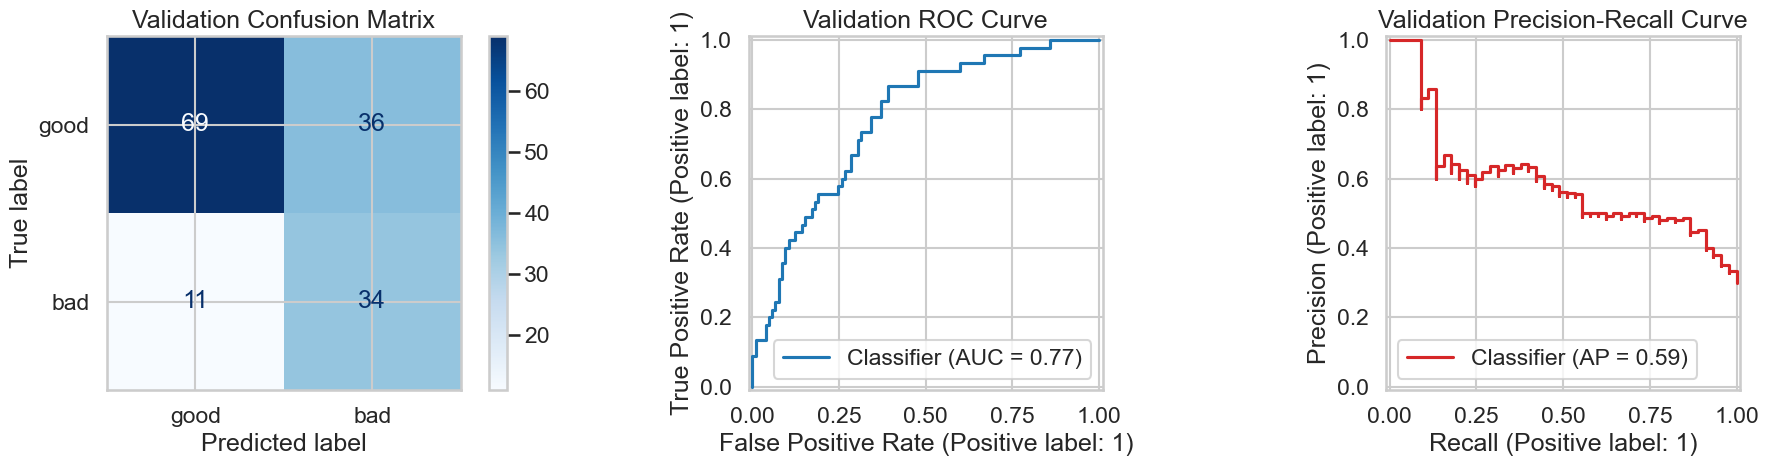

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred,
    display_labels=["good", "bad"],
    cmap="Blues",
    ax=axes[0],
)
axes[0].set_title("Validation Confusion Matrix")

RocCurveDisplay.from_predictions(y_valid, y_valid_score, ax=axes[1], color="#1f77b4")
axes[1].set_title("Validation ROC Curve")

PrecisionRecallDisplay.from_predictions(y_valid, y_valid_score, ax=axes[2], color="#d62728")
axes[2].set_title("Validation Precision-Recall Curve")

plt.tight_layout()
plt.show()

### Baseline Model Interpretation

The best baseline model shows reasonable ability to separate good-risk and bad-risk applicants. The validation ROC-AUC is approximately 0.77, suggesting the model ranks risky applicants better than random guessing.

The confusion matrix shows that the model correctly identifies 34 out of 45 bad-risk applicants, meaning it captures most of the risky cases. However, it also incorrectly flags 36 good-risk applicants as bad risk. This suggests the model is conservative: it prioritizes detecting bad-risk applicants, but at the cost of rejecting or reviewing some good applicants.

For a credit risk setting, this tradeoff may be acceptable depending on the lender's risk appetite. The next stage should compare stronger models and later tune the decision threshold rather than relying only on the default 0.50 classification threshold.


## 10. Save Baseline Model Results

Save the validation results so the next notebook can compare advanced models against these baselines.

In [ ]:
tables_dir = project_root / "artifacts" / "tables"
profiles_dir = project_root / "artifacts" / "profiles"
tables_dir.mkdir(parents=True, exist_ok=True)
profiles_dir.mkdir(parents=True, exist_ok=True)

results_path = tables_dir / "baseline_model_validation_results.csv"
validation_results_df.to_csv(results_path, index=False)

summary_path = profiles_dir / "baseline_model_summary.json"
baseline_summary = {
    "random_state": RANDOM_STATE,
    "split_strategy": "stratified 70/15/15 split",
    "best_baseline_model": best_model_name,
    "validation_results": validation_results_df.to_dict(orient="records"),
    "note": "Test set remains untouched for final comparison.",
}

with summary_path.open("w") as f:
    json.dump(baseline_summary, f, indent=2)

results_path, summary_path

(PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/baseline_model_validation_results.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/profiles/baseline_model_summary.json'))

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 341, in dispatch_control
    await self.process_control(msg)
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 347, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/ana

## 11. Baseline Modeling Decision Summary


The baseline stage compares a naive classifier, logistic regression, and a shallow decision tree. The best validation baseline should become the benchmark for advanced models.

Accuracy is not enough for credit risk. Later model selection should focus on recall for bad-risk cases, precision-recall tradeoffs, ROC-AUC, PR-AUC, calibration, and business threshold strategy.
